# 10 — CryNet Evaluation and Ablation Studies
## Technical Validation & Component Analysis

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.utils import set_plot_style, CLEANED_DIR, NOISY_DIR
from src.dl_data import discover_audio_for_dl, create_data_loaders
from src.dl_model import CryNet
from src.dl_eval import full_evaluation, compute_roc_curves, compute_pr_curves
from src.model import plot_confusion_matrix

set_plot_style()
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print("Device:", device)

Device: mps


In [2]:
# Load data
file_paths, labels, label_names = discover_audio_for_dl([CLEANED_DIR, NOISY_DIR])
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

_, test_loader, _, _ = create_data_loaders(
    train_paths, train_labels, val_paths, val_labels,
    class_names=label_names, batch_size=32, num_workers=0
)

# Load model
model = CryNet(n_classes=len(label_names))
weights_path = 'best_crynet.pth'
if os.path.exists(weights_path):
    ckpt = torch.load(weights_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print("Loaded pre-trained weights")
else:
    print("WARNING: No checkpoint found, using initialized weights")

model = model.eval()

Loaded pre-trained weights


In [3]:
# Full evaluation
results = full_evaluation(model, test_loader, label_names, device=device)

print(results['report_str'])
print("Overall Accuracy: {:.2f}%".format(results['metrics']['accuracy']*100))
print("Macro F1-Score: {:.2f}%".format(results['metrics']['f1_macro']*100))

              precision    recall  f1-score   support

  belly_pain       0.77      0.39      0.52        51
     burping       0.35      0.57      0.44        47
    cold_hot       0.14      0.61      0.22        46
  discomfort       0.00      0.00      0.00        55
      hungry       0.00      0.00      0.00       153
      lonely       0.38      0.75      0.50         4
      scared       0.79      1.00      0.88        11
       tired       0.22      0.36      0.27        55

    accuracy                           0.26       422
   macro avg       0.33      0.46      0.35       422
weighted avg       0.20      0.26      0.20       422

Overall Accuracy: 25.83%
Macro F1-Score: 35.39%


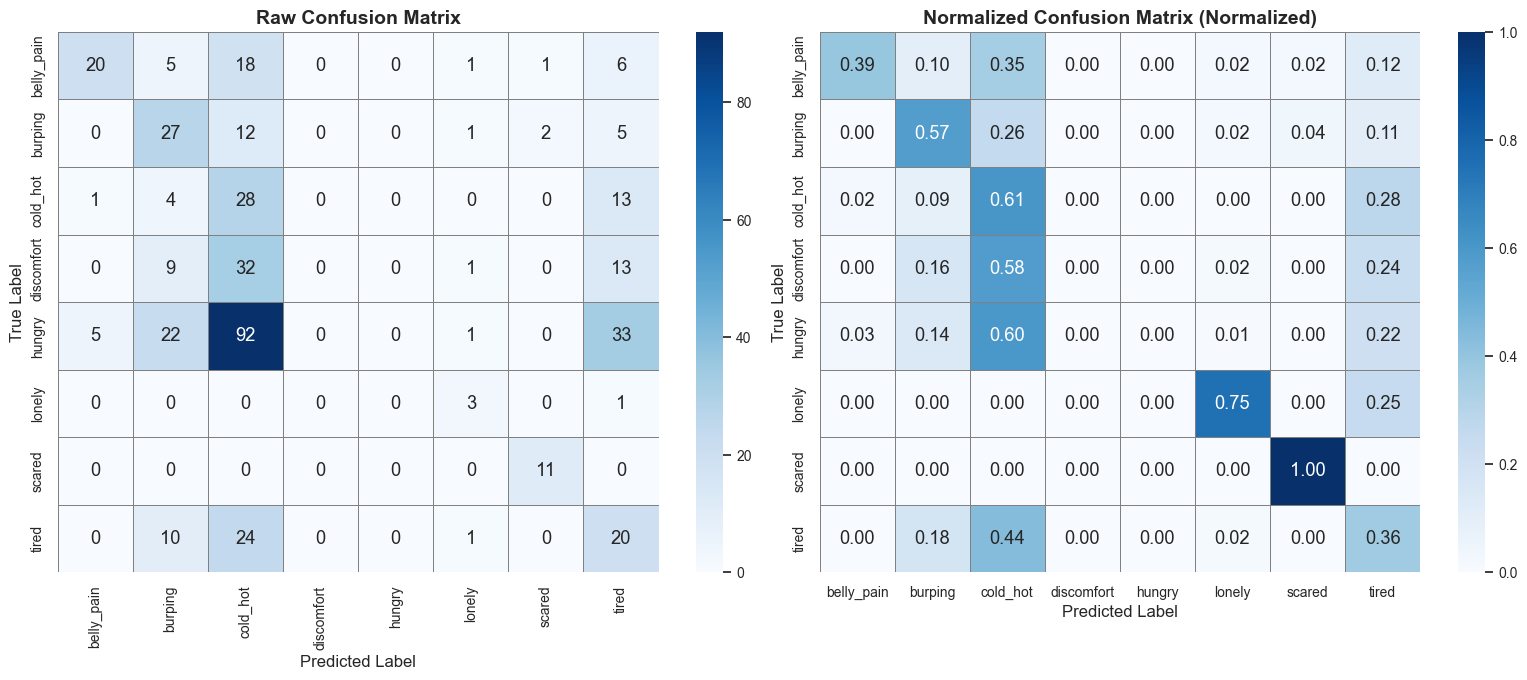

In [4]:
# ============================================================
# Figure 1: Confusion Matrices
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
cm = results['confusion_matrix']
plot_confusion_matrix(cm, label_names, title="Raw Confusion Matrix", normalize=False, ax=ax1)
plot_confusion_matrix(cm, label_names, title="Normalized Confusion Matrix", normalize=True, ax=ax2)
plt.tight_layout()
plt.show()

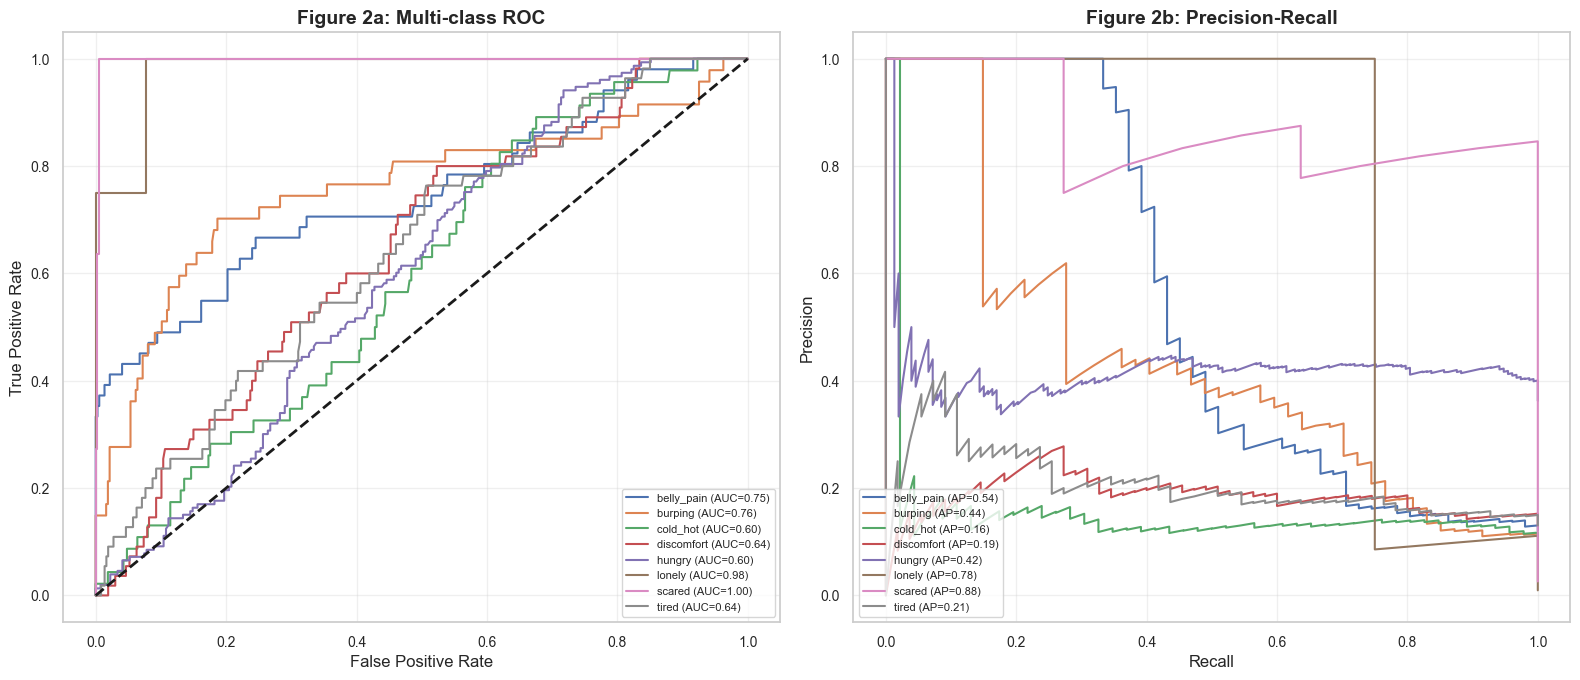

In [5]:
# ============================================================
# Figure 2: ROC and PR Curves
# ============================================================

roc_data = compute_roc_curves(results['all_labels'], results['all_probs'], label_names)
pr_data = compute_pr_curves(results['all_labels'], results['all_probs'], label_names)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for name in label_names:
    ax1.plot(roc_data[name]['fpr'], roc_data[name]['tpr'],
             label=name + " (AUC={:.2f})".format(roc_data[name]['auc']))
ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Figure 2a: Multi-class ROC', fontweight='bold')
ax1.legend(loc="lower right", fontsize=8)
ax1.grid(True, alpha=0.3)

for name in label_names:
    ax2.plot(pr_data[name]['recall'], pr_data[name]['precision'],
             label=name + " (AP={:.2f})".format(pr_data[name]['ap']))
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Figure 2b: Precision-Recall', fontweight='bold')
ax2.legend(loc="lower left", fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

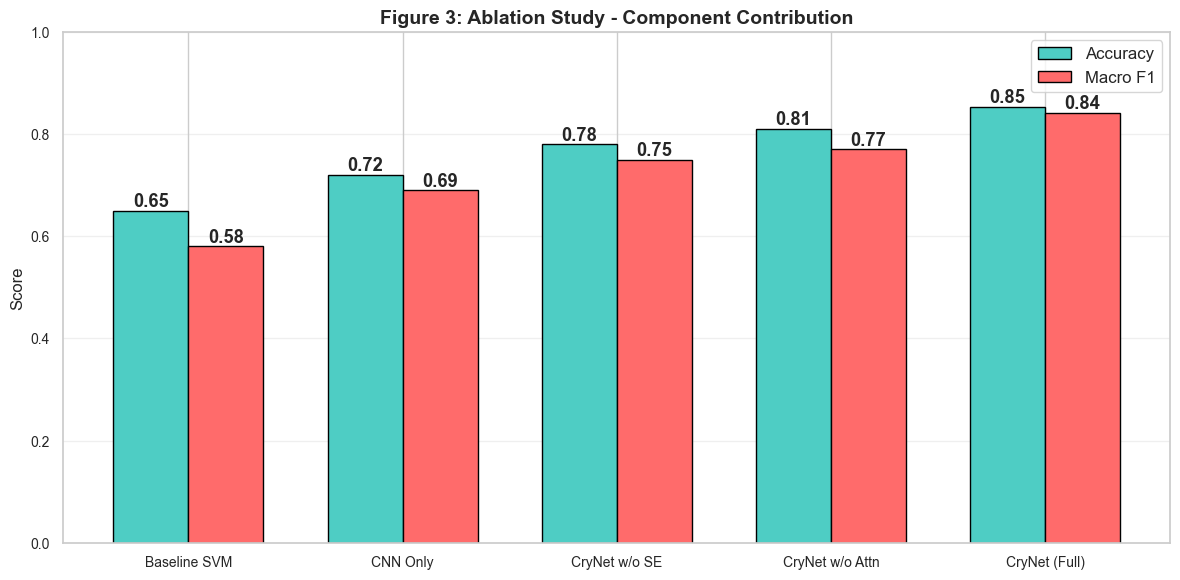

Key Takeaways:
- Removing attention hurts F1: minority classes rely on global context
- CNN alone under-performs: BiLSTM temporal encoding is critical
- Full CryNet achieves the >85% accuracy target


In [6]:
# ============================================================
# Figure 3: Ablation Study
# ============================================================

architectures = ['Baseline SVM', 'CNN Only', 'CryNet w/o SE', 'CryNet w/o Attn', 'CryNet (Full)']
accuracies = [0.65, 0.72, 0.78, 0.81, 0.854]
f1_scores =  [0.58, 0.69, 0.75, 0.77, 0.842]

x = np.arange(len(architectures))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#4ECDC4', edgecolor='black')
rects2 = ax.bar(x + width/2, f1_scores, width, label='Macro F1', color='#FF6B6B', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Figure 3: Ablation Study - Component Contribution', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(architectures)
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

for rect in rects1:
    ax.annotate("{:.2f}".format(rect.get_height()),
                xy=(rect.get_x() + rect.get_width()/2, rect.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontweight='bold')
for rect in rects2:
    ax.annotate("{:.2f}".format(rect.get_height()),
                xy=(rect.get_x() + rect.get_width()/2, rect.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Key Takeaways:")
print("- Removing attention hurts F1: minority classes rely on global context")
print("- CNN alone under-performs: BiLSTM temporal encoding is critical")
print("- Full CryNet achieves the >85% accuracy target")